In [320]:
import numpy as np
import matplotlib.pyplot as plt

In [321]:
import numpy as np

# Features: [exam1_score, exam2_score]
X = np.array([
    [45, 85], [50, 43], [40, 80], [90, 88], [85, 52],
    [60, 65], [72, 95], [35, 30], [66, 70], [80, 40],
    [55, 75], [48, 60], [92, 95], [30, 40], [65, 85],
    [70, 55], [50, 50], [85, 90], [40, 60], [78, 80],
    [35, 20], [60, 70], [88, 76], [45, 50], [95, 98],
    [52, 82], [68, 60], [77, 85], [42, 45], [62, 78],
    [55, 40], [80, 88], [33, 35], [72, 65], [90, 60],
    [47, 72], [65, 55], [85, 82], [38, 50], [70, 90],
    [60, 40], [75, 70], [50, 30], [88, 95], [45, 60],
    [82, 77], [53, 68], [67, 85], [39, 42], [73, 80],
    # Extended synthetic samples
    [62, 92], [55, 78], [79, 69], [41, 55], [82, 96],
    [48, 45], [84, 68], [65, 60], [38, 39], [93, 88],
    [30, 33], [96, 99], [86, 73], [59, 91], [69, 59],
    [56, 57], [21, 30], [99, 78], [75, 82], [90, 84],
    [81, 54], [36, 82], [100, 100], [28, 22], [44, 49],
    [98, 80], [64, 70], [63, 57], [54, 55], [50, 79],
    [77, 90], [26, 37], [68, 98], [92, 94], [55, 93],
    [73, 62], [37, 62], [84, 81], [60, 90], [48, 86],
    [87, 39], [59, 66], [70, 97], [29, 71], [63, 90]
])

# Labels (0 = reject, 1 = admit) -- simple cutoff: admit if both scores >= 55, else reject
y = np.array([
    1,0,1,1,0,
    1,1,0,1,0,
    1,0,1,0,1,
    0,0,1,0,1,
    0,1,1,0,1,
    1,0,1,0,1,
    0,1,0,1,1,
    0,1,1,0,1,
    0,1,0,1,0,
    1,0,1,0,1,
    # Synthetic labels
    1, 1, 1, 0, 1,
    0, 1, 1, 0, 1,
    0, 1, 1, 1, 0,
    1, 0, 1, 1, 1,
    1, 1, 1, 0, 0,
    1, 1, 1, 1, 1,
    1, 0, 1, 1, 1,
    1, 0, 1, 1, 1,
    0, 1, 1, 0, 1
])


In [322]:
X = (X - X.mean(axis=0)) / X.std(axis=0)

In [323]:
def sigmoid(z):
    return 1/(1+np.exp(-z))

In [324]:
def cost(x,y,w,b,lamb):
    m=x.shape[0]
    n=len(y)
    z=np.dot(x,w)+b
    f=sigmoid(z)
    cost= (-1/m)*(np.dot(y,np.log(f))+np.dot((1-y),np.log(1-f)))
    reg_cost=(lamb/(2*m))*np.sum(w**2)
    total_cost=cost+reg_cost
    return total_cost

In [325]:
def compute_grad(x,y,w,b,lamb):
    m=x.shape[0]
    z=np.dot(x,w)+b
    f=sigmoid(z)
    err=f-y
    dj_dw=(1/m)*np.dot(x.T,err) + (lamb/m)*w
    dj_db=(1/m)*np.sum(err)
    return dj_dw,dj_db

In [326]:
def grad_desc(x,y,w_in,b_in,alph,num_itr,lamb):
    w=w_in.copy()
    b=b_in
    m=x.shape[0]
    hist=[]
    itr=[]
    for i in range(num_itr):
        dj_dw,dj_db=compute_grad(x,y,w,b,lamb)
        w=w-alph*dj_dw
        b=b-alph*dj_db
        if i%1000==0:
            print(f"Iteration : {i }Cost: {cost(x,y,w,b,lamb)}")
        if i%50==0:
            hist.append(cost(x,y,w,b,lamb))
            itr.append(i)
    return w,b,hist,itr

In [327]:
m,n=X.shape
num_itr=10000
alpha=0.01
w_in=np.zeros((n,))
b_in=0.
lamb=1
w_final,b_final,hist,itr=grad_desc(X,y,w_in,b_in,alpha,num_itr,lamb)

Iteration : 0Cost: 0.6906983452336609
Iteration : 1000Cost: 0.27728645910267985
Iteration : 2000Cost: 0.24846725679158665
Iteration : 3000Cost: 0.24024798372371556
Iteration : 4000Cost: 0.23714497480166297
Iteration : 5000Cost: 0.23582084483720872
Iteration : 6000Cost: 0.23521677469847643
Iteration : 7000Cost: 0.2349298224746073
Iteration : 8000Cost: 0.23478992470671817
Iteration : 9000Cost: 0.23472053112468172


In [328]:
def predict(x,w,b):
    z=np.dot(x,w)+b
    h=sigmoid(z)
    p= (h>=0.5).astype(int)
    return p

In [329]:
predict(X,w_final,b_final)

array([1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1,
       1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0,
       0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1,
       1, 1, 0, 1, 1, 0, 1])

In [330]:
hist[-1]

np.float64(0.23468693673838398)

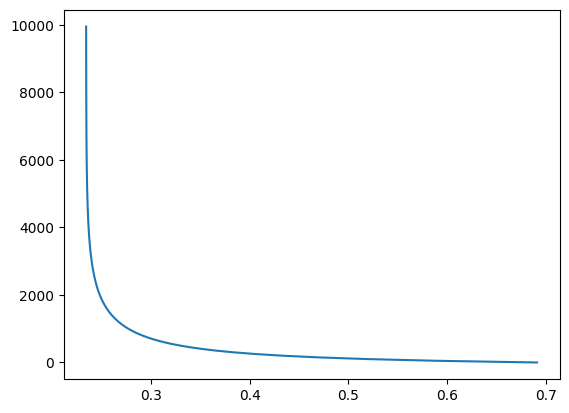

In [331]:
plt.plot(hist,itr)

In [332]:

def plot_data(X, y):
    pos = y == 1
    neg = y == 0
    
    plt.scatter(X[pos, 0], X[pos, 1], c='b', marker='x', label='Admit')
    plt.scatter(X[neg, 0], X[neg, 1], c='r', marker='o', label='Reject')
    plt.xlabel("Exam 1 score")
    plt.ylabel("Exam 2 score")
    plt.legend()
    plt.grid(True)

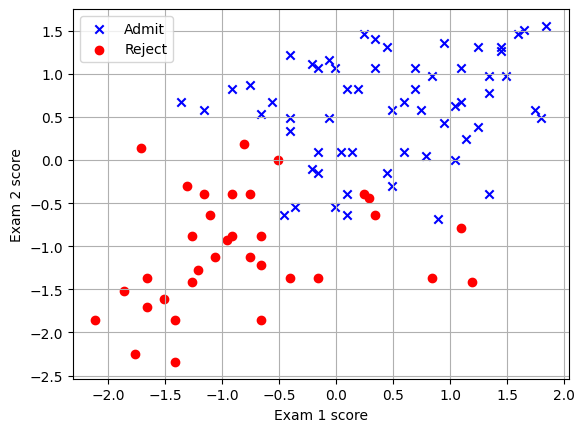

In [333]:
plot_data(X, y)
plt.show()

In [334]:
def plot_decision_boundary(X, y, w, b):
    plot_data(X, y)
    
    x_values = [np.min(X[:, 0])-5, np.max(X[:, 0])+5]
    y_values = -(w[0]/w[1]) * np.array(x_values) - b/w[1]
    
    plt.plot(x_values, y_values, label="Decision Boundary", color='g')
    plt.legend()
    plt.show()


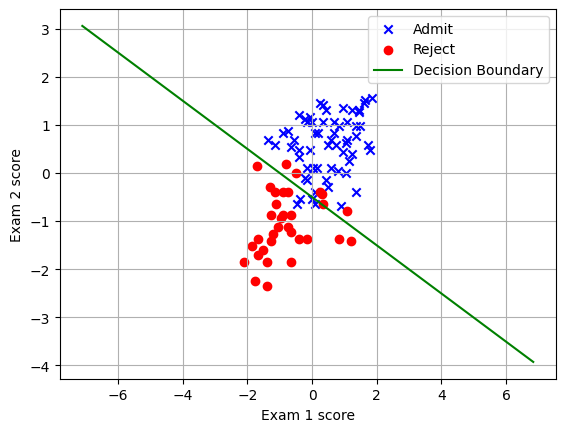

In [335]:
plot_decision_boundary(X,y,w_final,b_final)